Готовая база для Markdown:
v3.0:  https://drive.google.com/file/d/1e4U1IoxumnkW0ttZ-n3CDnDMKX4Qvco-/view?usp=sharing

In [ ]:
!pip install -q langchain_openai==0.0.2 faiss-cpu==1.7.4 openai==1.6.1 tiktoken==0.5.2 langchain_community==0.0.11 langchain==0.1.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 41.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.4/225.4 kB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.0/798.0 kB 28.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.9/302.9 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.9/302.9 kB 23.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.text_splitter import RecursiveCharacterTextSplitter, MarkdownHeaderTextSplitter, CharacterTextSplitter
import re
import requests
import openai
from openai import OpenAI
import os
from langchain.docstore.document import Document
import tiktoken
import matplotlib.pyplot as plt
from google.colab import userdata

In [ ]:
# Получение API ключа из пользовательских данных Colab и установка его как переменной среды
key = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = key

# Создание клиента OpenAI с использованием API ключа из переменных среды
client = OpenAI()

In [ ]:
#Готовая база для Markdown: v3.0: https://drive.google.com/file/d/1e4U1IoxumnkW0ttZ-n3CDnDMKX4Qvco-/view?usp=sharing
id_doc_markdown = '1e4U1IoxumnkW0ttZ-n3CDnDMKX4Qvco-'

In [ ]:
# функция для загрузки документа по doc_id из гугл драйв в текстовом формате
def load_doc_id_text(file_id):
    # Download the document as plain text
    response = requests.get(f'https://drive.google.com/uc?export=download&id={file_id}')
    response.raise_for_status()
    text = response.text

    return text

In [ ]:
data_from_markdown = load_doc_id_text(id_doc_markdown)

In [ ]:
data_from_markdown[-100:]

'я информации на оборотной стороне свидетельства о поверке при оформлении его на бумажном носителе).\n'

In [ ]:
def num_tokens_from_string(string: str, encoding_name: str) -> int:
      """Возвращает количество токенов в строке"""
      encoding = tiktoken.get_encoding(encoding_name)
      num_tokens = len(encoding.encode(string))
      return num_tokens

def split_text(text, max_count):
    headers_to_split_on = [
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
        ("####", "Header 4"),
        ("#####", "Header 5"),
    ]

    markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
    fragments = markdown_splitter.split_text(text)

    # Подсчет токенов для каждого фрагмента и построение графика
    fragment_token_counts = [num_tokens_from_string(fragment.page_content, "cl100k_base") for fragment in fragments]
    plt.hist(fragment_token_counts, bins=50, alpha=0.5, label='Fragments')
    plt.title('Распределение количества фрагментных токенов')
    plt.xlabel('Количество токенов')
    plt.ylabel('Частота')
    plt.show()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=max_count,
        chunk_overlap=0,
        length_function=lambda x: num_tokens_from_string(x, "cl100k_base")
    )

    source_chunks = [
        Document(page_content=chunk, metadata=fragment.metadata)
        for fragment in fragments
        for chunk in splitter.split_text(fragment.page_content)
    ]

    # Подсчет токенов для каждого source_chunk и построение графика
    source_chunk_token_counts = [num_tokens_from_string(chunk.page_content, "cl100k_base") for chunk in source_chunks]
    plt.hist(source_chunk_token_counts, bins=20, alpha=0.5, label='Source Chunks')
    plt.title('Распределение количества токенов исходного блока')
    plt.xlabel('Количество токенов')
    plt.ylabel('Частота')
    plt.show()

    return source_chunks, fragments

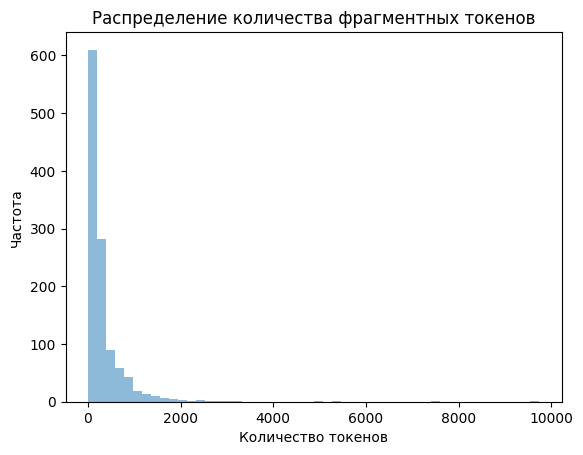

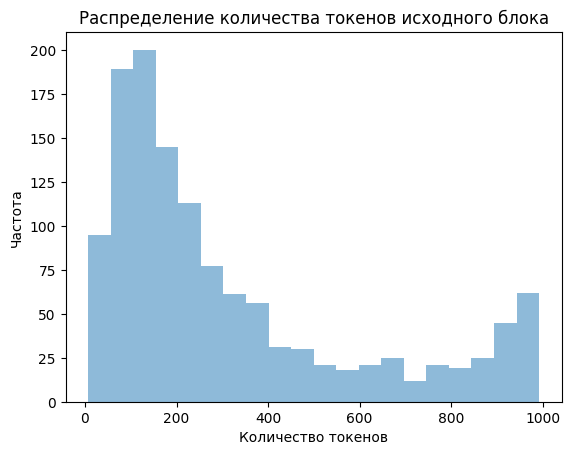

Общее количество чанков:  1266
Первый чанк  page_content='Документ предоставлен КонсультантПлюс'
Крайний чанк  page_content='5. На оборотной стороне свидетельств о поверке при оформлении их на бумажном носителе или в свидетельствах о поверке, оформляемых в виде электронного документа, по заявлению владельцев средств измерений или лиц, представивших средства измерений на поверку, или по согласованию с ними может указываться дополнительная информация, относящаяся к средствам измерений, месту их установки, особенностям поверки, включая сведения о пломбах, предотвращающих доступ к местам настройки (регулировки) средств измерений, принадлежности средств измерений (сведения о владельцах средств измерений), а также информация о прилагаемых к свидетельству о поверке документах (при невозможности размещения информации на оборотной стороне свидетельства о поверке при оформлении его на бумажном носителе).' metadata={'Header 1': 'ТРЕБОВАНИЯ К СОДЕРЖАНИЮ СВИДЕТЕЛЬСТВА О ПОВЕРКЕ', 'Header 2': 'пункт

In [ ]:
source_chunks, fragments = split_text(data_from_markdown, 1000)
print("Общее количество чанков: ",len(source_chunks))
print("Первый чанк ", source_chunks[0])
print("Крайний чанк ", source_chunks[len(source_chunks)-1])

In [ ]:
source_chunks[8]

Document(page_content='2. Действие настоящего Федерального закона не распространяется на стандарты, которые не относятся к документам по стандартизации, предусмотренным статьей 14 настоящего Федерального закона.', metadata={'Header 1': 'РОССИЙСКАЯ ФЕДЕРАЦИЯ ФЕДЕРАЛЬНЫЙ ЗАКОН О СТАНДАРТИЗАЦИИ В РОССИЙСКОЙ ФЕДЕРАЦИИ', 'Header 2': 'Статья 1. Предмет, цели и сфера регулирования настоящего Федерального закона', 'Header 3': 'пункт 2.'})

In [ ]:
# Инструкция в system
system = "Ты юридический консультант по метрологическому обеспечению, ответь на вопрос клиента на основе документа с информацией. При ответе ссылайся на статьи, главы и пункты нормативной документации, указаннай в заголовке документа. Не указывай из какого отрывка документа взята информация (Так ответчать не нужно: 'Из документа №2 следует...'). Не придумывай ничего от себя, отвечай максимально по представленным документам. Не отвечай на вопросы, не касающиеся документа."

In [ ]:
# Инициализирум модель эмбеддингов
embeddings = OpenAIEmbeddings()

# Создадим индексную базу из разделенных фрагментов текста
db = FAISS.from_documents(source_chunks, embeddings)

In [ ]:
def answer_index(system, topic, search_index, verbose=0):

    # Поиск релевантных отрезков из базы знаний
    docs = search_index.similarity_search(topic, k=4)
    if verbose: print('\n ===========================================: ')
    #message_content = re.sub(r'\n{2}', ' ', '\n '.join([f'\n =======\nОтрывок документа №{i+1}\n=====================' + doc.page_content + '\n' for i, doc in enumerate(docs)]))
    message_content = re.sub(r'\n{2}', ' ', '\n '.join([f'\n =======\nОтрывок документа №{i+1}\n=====' + str(doc.metadata) + '\n================' + str(doc.page_content) + '\n' for i, doc in enumerate(docs)]))
    if verbose: print('message_content :\n ======================================== \n', message_content)
    client = OpenAI()
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": f"Ответь на вопрос. Документ с информацией для ответа: {message_content}\n\nВопрос пользователя: \n{topic}"}
    ]

    if verbose: print('\n ===========================================: ')

    completion = client.chat.completions.create(
        model="gpt-4o",
        messages=messages,
        temperature=0                           # укажите температуру
    )
    answer = completion.choices[0].message.content
    return message_content, answer  # возвращает ответ

#Проверяем работу нейро-консультанта на вопросах из базы doc_markdown_v3.0.txt

In [ ]:
# 1 вопрос пользователя
topic= "В настоящий момент в нашей организации находятся в эксплуатации технические манометры утвержденного типа, прошедшие поверку в соответствии с положениями ФЗ № 102-ФЗ в конструктивном исполнении, не предусматривающем места установки пломб, содержащих изображение знака поверки. Сведения о месте установки пломб в том числе отсутствуют в описании типа СИ на манометры. Прошу Вас дать разъяснение о соответствии таких средств измерений требованиям ФЗ № 102-ФЗ и возможности их применения для измерений, на которые распространяется сфера государственного регулирования обеспечения единства измерений."
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ПРИКАЗ от 31 июля 2020 г. N 2510 ОБ УТВЕРЖДЕНИИ ПОРЯДКА ПРОВЕДЕНИЯ ПОВЕРКИ СРЕДСТВ ИЗМЕРЕНИЙ, ТРЕБОВАНИЙ К ЗНАКУ ПОВЕРКИ И СОДЕРЖАНИЮ СВИДЕТЕЛЬСТВА О ПОВЕРКЕ', 'Header 2': 'III. Поверка средств измерений', 'Header 3': 'пункт 20.'}
================20. В целях предотвращения доступа к узлам настройки (регулировки) средств измерений в местах, предусмотренных их конструкцией, по завершении поверки аккредитованным на поверку лицом устанавливаются пломбы, содержащие изображение знака поверки.  
Отрывок документа №2
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ПРИКАЗ от 31 июля 2020 г. N 2510 ОБ УТВЕРЖДЕНИИ ПОРЯДКА ПРОВЕДЕНИЯ ПОВЕРКИ СРЕДСТВ ИЗМЕРЕНИЙ, ТРЕБОВАНИЙ К ЗНАКУ ПОВЕРКИ И СОДЕРЖАНИЮ СВИДЕТЕЛЬСТВА О ПОВЕРКЕ', 'Header 2': 'I. Общие положения', 'Header 3': 'пункт 3.'}
================3. Поверке подлежат средства измерений утвержденного типа, предназначен

In [ ]:
# 2 вопрос пользователя
topic= "В мае купили прибор учета воды с отметкой о заводской поверке от 20.05.2022, 22 июля установили. Вопрос, как внести сведения о поверке в Федеральный информационный фонд по обеспечению единства измерений?"
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'ПОРЯДОК УСТАНОВЛЕНИЯ И ИЗМЕНЕНИЯ ИНТЕРВАЛА МЕЖДУ ПОВЕРКАМИ СРЕДСТВ ИЗМЕРЕНИЙ', 'Header 2': 'пункт 14.'}
================14. Сведения об установленных (измененных) интервалах между поверками включаются в Федеральный информационный фонд по обеспечению единства измерений в соответствии с порядком, предусмотренным частью 3 статьи 20 Федерального закона N 102-ФЗ.
Приложение N 2
к приказу Минпромторга России
от 28 августа 2020 г. N 2907  
Отрывок документа №2
====={'Header 1': 'ПОРЯДОК УСТАНОВЛЕНИЯ, ОТМЕНЫ МЕТОДИК ПОВЕРКИ И ВНЕСЕНИЯ ИЗМЕНЕНИЙ В НИХ', 'Header 2': 'пункт 17.'}
================17. В сведения об утвержденных типах средств измерений, содержащихся в Федеральном информационном фонде по обеспечению единства измерений, на основании принятых Федеральным агентством по техническому регулированию и метрологии решений вносятся изменения в сведения о методиках поверки в соответствии с порядком создания и ведения Федерального информационного фонда по

In [ ]:
# вопрос пользователя
topic= "Нужно внести в реестр Минпромторга металлические линейки, сделанные по госту и поставленные по государственному контракту. Что нам для этого нужно?"
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ФЕДЕРАЛЬНОЕ АГЕНТСТВО ПО ТЕХНИЧЕСКОМУ РЕГУЛИРОВАНИЮ И МЕТРОЛОГИИ ПРИКАЗ от 12 ноября 2018 г. N 2346 ОБ УТВЕРЖДЕНИИ АДМИНИСТРАТИВНОГО РЕГЛАМЕНТА ПО ПРЕДОСТАВЛЕНИЮ ФЕДЕРАЛЬНЫМ АГЕНТСТВОМ ПО ТЕХНИЧЕСКОМУ РЕГУЛИРОВАНИЮ И МЕТРОЛОГИИ ГОСУДАРСТВЕННОЙ УСЛУГИ ПО УТВЕРЖДЕНИЮ ТИПА СТАНДАРТНЫХ ОБРАЗЦОВ ИЛИ ТИПА СРЕДСТВ ИЗМЕРЕНИЙ', 'Header 3': 'Порядок осуществления административных процедур в электронной форме, в том числе с использованием Единого портала государственных и муниципальных услуг (функций)', 'Header 4': 'пункт 58.'}
================58. Прием и регистрация заявления осуществляются должностным лицом, ответственным за делопроизводство в Управлении, ответственным за предоставление государственной услуги.
(в ред. Приказа Росстандарта от 17.08.2020 N 1404)  
Отрывок документа №2
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ФЕДЕРАЛЬНОЕ АГЕНТСТВО ПО ТЕХНИЧЕСКО

In [ ]:
# вопрос пользователя Трансформаторы_ТПЛ-10
topic= "Поверители не выдают свидетельство о поверке (т.е. они их бракуют) на трансформаторы тока, ссылаясь на то, что во ФГИСе в утвержденных типах средств измерений фигурирует другой изготовитель. Насколько правомерны такие действия и что можно предпринять для решения проблемы."
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ПРИКАЗ от 31 июля 2020 г. N 2510 ОБ УТВЕРЖДЕНИИ ПОРЯДКА ПРОВЕДЕНИЯ ПОВЕРКИ СРЕДСТВ ИЗМЕРЕНИЙ, ТРЕБОВАНИЙ К ЗНАКУ ПОВЕРКИ И СОДЕРЖАНИЮ СВИДЕТЕЛЬСТВА О ПОВЕРКЕ', 'Header 2': 'I. Общие положения', 'Header 3': 'пункт 3.'}
================3. Поверке подлежат средства измерений утвержденного типа, предназначенные для применения в сфере государственного регулирования обеспечения единства измерений.
Средства измерений, не предназначенные для применения в сфере государственного регулирования обеспечения единства измерений, могут подвергаться поверке в добровольном порядке.
Средства измерений до ввода в эксплуатацию, а также после ремонта подлежат первичной поверке, а в процессе эксплуатации - периодической поверке. <3>
--------------------------------
<3> Часть 1 статьи 13 Федерального закона N 102-ФЗ.
Поверка средств измерений, применяемых в области обороны и безопасности государства, осуществл

In [ ]:
# вопрос пользователя О сведениях из Фонда об идентичности СИ
topic= 'Согласно ФЗ № 102 "Об обеспечении единства средств измерений" сведения о типах и средствах измерений вносятся в Федеральный информационный фонд по обеспечению единства средств измерений. Согласно пункту 4 приказа Минпромторга России № 2906 от 28.08.2020 "Об утверждении порядка создания и ведения Федерального информационного фонда по обеспечению единства измерений, передачи сведений в него и внесения изменений в данные сведений, предоставления содержащихся в нем документов и сведений" организация ведения данного Фонда возложена на Федерального агентство по техническому регулированию и метрологии. В связи с этим прошу в ответном письме указать являются ли сходными (идентичными, имеющими одинаковый метод работы, способы поверки) типы средств измерений, зарегистрированные в Фонде под различными номерами.'
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'ПОРЯДОК УСТАНОВЛЕНИЯ, ОТМЕНЫ МЕТОДИК ПОВЕРКИ И ВНЕСЕНИЯ ИЗМЕНЕНИЙ В НИХ', 'Header 2': 'пункт 17.'}
================17. В сведения об утвержденных типах средств измерений, содержащихся в Федеральном информационном фонде по обеспечению единства измерений, на основании принятых Федеральным агентством по техническому регулированию и метрологии решений вносятся изменения в сведения о методиках поверки в соответствии с порядком создания и ведения Федерального информационного фонда по обеспечению единства измерений, предусмотренным частью 3 статьи 20 Федерального закона N 102-ФЗ.
Приложение N 3
к приказу Минпромторга России
от 28 августа 2020 г. N 2907  
Отрывок документа №2
====={'Header 1': 'РОССИЙСКАЯ ФЕДЕРАЦИЯ ФЕДЕРАЛЬНЫЙ ЗАКОН ОБ ОБЕСПЕЧЕНИИ ЕДИНСТВА ИЗМЕРЕНИЙ', 'Header 2': 'Статья 12. Утверждение типа стандартных образцов или типа средств измерений', 'Header 3': 'пункт 6.'}
================6. Сведения об утвержденных типах стандартных образцов и 

In [ ]:
# вопрос пользователя О чем ПРИКАЗ от 28 августа 2020 г. N 2906 - а ответ то не находится(((
topic= 'О чем ПРИКАЗ от 28 августа 2020 г. N 2906'
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ПРИКАЗ от 25 июня 2013 г. N 971 ОБ УТВЕРЖДЕНИИ АДМИНИСТРАТИВНОГО РЕГЛАМЕНТА ПО ПРЕДОСТАВЛЕНИЮ ФЕДЕРАЛЬНЫМ АГЕНТСТВОМ ПО ТЕХНИЧЕСКОМУ РЕГУЛИРОВАНИЮ И МЕТРОЛОГИИ ГОСУДАРСТВЕННОЙ УСЛУГИ ПО ОТНЕСЕНИЮ ТЕХНИЧЕСКИХ СРЕДСТВ К СРЕДСТВАМ ИЗМЕРЕНИЙ', 'Header 2': 'III. Состав, последовательность и сроки выполнения административных процедур (действий), требования к порядку их выполнения, в том числе особенности выполнения административных процедур (действий) в электронной форме', 'Header 3': 'Порядок осуществления административных процедур в электронной форме, в том числе с использованием федеральной государственной информационной системы "Единый портал государственных и муниципальных услуг (функций)"'}
================(введено Приказом Минпромторга России от 23.08.2017 N 2872)  
Отрывок документа №2
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ПРИКАЗ от 25 июня 201

In [ ]:
# вопрос пользователя Почему идет дождь?
topic= 'Почему идет дождь?'
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'РЕКОМЕНДАЦИИ ПО МЕЖГОСУДАРСТВЕННОЙ СТАНДАРТИЗАЦИИ ГОСУДАРСТВЕННАЯ СИСТЕМА ОБЕСПЕЧЕНИЯ ЕДИНСТВА ИЗМЕРЕНИЙ МЕТРОЛОГИЯ ОСНОВНЫЕ ТЕРМИНЫ И ОПРЕДЕЛЕНИЯ State system for ensuring the uniformity of measurements. Metrology. Basic terms and definitions РМГ 29-2013', 'Header 3': 'пункт 1.'}
================1. Разработаны Федеральным государственным унитарным предприятием "Всероссийский научно-исследовательский институт метрологии им. Д.И. Менделеева" (ФГУП "ВНИИМ им. Д.И. Менделеева").  
Отрывок документа №2
====={'Header 1': 'РОССИЙСКАЯ ФЕДЕРАЦИЯ ФЕДЕРАЛЬНЫЙ ЗАКОН ОБ ОБЕСПЕЧЕНИИ ЕДИНСТВА ИЗМЕРЕНИЙ', 'Header 2': 'Статья 15. Федеральный государственный метрологический контроль (надзор)', 'Header 3': 'пункт 4.'}
================4. Положение о федеральном государственном метрологическом контроле (надзоре) утверждается Правительством Российской Федерации.  
Отрывок документа №3
====={'Header 1': 'ПРАВИТЕЛЬСТВО РОССИЙСКОЙ ФЕДЕРАЦИИ ПОСТАНОВЛЕНИЕ от 29 июня 202

In [ ]:
import pandas as pd

# Загрузка перечня вопросов-ответов из файла Excel в DataFrame
df = pd.read_excel('output.xlsx')
df.head()

,№ п/п,Вопрос,Идеальный ответ,Ответ GPT
0,1,Какие предъявляются требования к измерениям пр...,Законодательство Российской Федерации об обесп...,NaN
1,2,Какой нормативный правовой акт устанавливает п...,В соответствии с частью 1 статьи 9 Федеральног...,NaN
2,3,Допустимо ли проведение процедуры калибровки с...,Сфера государственного регулирования обеспечен...,NaN
3,4,Возможно ли использование средств измерений в ...,В связи с отсутствием в Вашем обращении информ...,NaN
4,5,"Нужно ли поверять все средства измерений, прим...","Управление метрологии, государственного контро...",NaN


In [ ]:
def answer_index_no_message(system, topic, search_index, verbose=0):

    # Поиск релевантных отрезков из базы знаний
    docs = search_index.similarity_search(topic, k=4)
    if verbose: print('\n ===========================================: ')
    #message_content = re.sub(r'\n{2}', ' ', '\n '.join([f'\n =======\nОтрывок документа №{i+1}\n=====================' + doc.page_content + '\n' for i, doc in enumerate(docs)]))
    message_content = re.sub(r'\n{2}', ' ', '\n '.join([f'\n =======\nОтрывок документа №{i+1}\n=====' + str(doc.metadata) + '\n================' + str(doc.page_content) + '\n' for i, doc in enumerate(docs)]))
    if verbose: print('message_content :\n ======================================== \n', message_content)
    client = OpenAI()
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": f"Ответь на вопрос. Документ с информацией для ответа: {message_content}\n\nВопрос пользователя: \n{topic}"}
    ]

    if verbose: print('\n ===========================================: ')

    completion = client.chat.completions.create(
        model="gpt-4o",
        messages=messages,
        temperature=0                           # укажите температуру
    )
    answer = completion.choices[0].message.content
    return answer  # возвращает ответ

In [ ]:
# Извлечение данных из столбца 'Вопрос' по очереди и запись ответа GPT в столбец Ответ GPT-4o

for question in df['Вопрос']:
    df['Ответ GPT-4o'] = df['Вопрос'].apply(lambda x: answer_index_no_message(system, x, db))

In [ ]:
df

,№ п/п,Вопрос,Идеальный ответ,Ответ GPT,Ответ GPT-4o
0,1,Какие предъявляются требования к измерениям пр...,Законодательство Российской Федерации об обесп...,NaN,При проведении работ по обеспечению безопасных...
1,2,Какой нормативный правовой акт устанавливает п...,В соответствии с частью 1 статьи 9 Федеральног...,NaN,"Перечень измерений, реализуемых в сфере госуда..."
2,3,Допустимо ли проведение процедуры калибровки с...,Сфера государственного регулирования обеспечен...,NaN,"Да, проведение процедуры калибровки средств из..."
3,4,Возможно ли использование средств измерений в ...,В связи с отсутствием в Вашем обращении информ...,NaN,"Использование средств измерений, не внесенных ..."
4,5,"Нужно ли поверять все средства измерений, прим...","Управление метрологии, государственного контро...",NaN,"Средства измерений, применяемые в технологичес..."
5,6,"Как определить, относятся ли измерения, провод...",В соответствии со статьей 9 Федерального закон...,NaN,"Для определения, относятся ли измерения, прово..."
6,7,Можно ли применять средство измерений неутверж...,Для применения средства измерений неутвержден...,NaN,Средство измерений неутвержденного типа не мож...
7,8,Просим рассмотреть предложения по доработке пр...,В соответствии с частью 4 статьи 13 Федерально...,NaN,"Согласно статье 13 Федерального закона ""Об обе..."
8,9,"Каковы особенности поверки средств измерений, ...",Согласно пункту 13 Порядка проведения поверки ...,NaN,"Особенности поверки средств измерений, поступи..."
9,10,Можете ли Вы предоставить выписку из Федеральн...,Предоставление из Федерального информационного...,NaN,"Да, выписка о результатах поверки средств изме..."


In [ ]:
#Сохраним ответы обученной LLM в файл
df.to_excel('answer_GPT-o_no_message.xlsx', index=False)